In [16]:
%pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\tempe\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [9]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [10]:
# ==========================================
# STEP 1: Load the dataset
# ==========================================
print("Loading dataset...")
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "fronkongames/steam-games-dataset",
    "games.csv"
)

Loading dataset...


C:\Users\tempe\AppData\Local\Temp\ipykernel_29296\849704322.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [11]:
# ==========================================
# STEP 2: Fix Header Shift & Clean Data
# ==========================================
print("Cleaning data and engineering features...")
# Fix the missing 'AppID' header that caused the index shift
df = df.reset_index() 
df.rename(columns={'index': 'AppID', 'AppID': 'Name'}, inplace=True)

# Standardize column names based on the shift
rename_map = {
    "positive_ratings": "Positive",
    "negative_ratings": "Negative",
    "average_playtime": "Average playtime forever",
    "median_playtime": "Median playtime forever",
    "price": "Price",
    "achievements": "Achievements",
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

required_cols = ["Price", "Positive", "Negative", "Average playtime forever", "Achievements"]
available_cols = [c for c in required_cols if c in df.columns]

# Fill missing numeric values with 0
for c in available_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

# Engineer new features
df["Total Reviews"] = df["Positive"] + df["Negative"]
df["Review Score"] = np.where(
    df["Total Reviews"] > 0,
    df["Positive"] / df["Total Reviews"],
    0.5  # Neutral score if no reviews exist
)

# Filter out ghost listings and extreme outliers
clean_df = df[df["Total Reviews"] >= 10].copy()
for c in ["Price", "Average playtime forever", "Total Reviews"]:
    cap = clean_df[c].quantile(0.99)
    clean_df = clean_df[clean_df[c] <= cap]
clean_df = clean_df.reset_index(drop=True)

Cleaning data and engineering features...


In [12]:
# ==========================================
# STEP 3: Prepare Features for Clustering
# ==========================================
feature_cols = ["Price", "Review Score", "Average playtime forever", "Total Reviews", "Achievements"]
X = clean_df[feature_cols].copy()

# Log-transform highly skewed features
for c in ["Average playtime forever", "Total Reviews"]:
    X[c] = np.log1p(X[c])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
# ==========================================
# STEP 4: K-Means Clustering Model
# ==========================================
print("Running K-Means Clustering...")
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
clean_df["Cluster"] = kmeans.fit_predict(X_scaled)

# Calculate silhouette score using a sample to prevent MemoryError
sil_score = silhouette_score(X_scaled, clean_df["Cluster"], sample_size=2000, random_state=42)
print(f"Final Silhouette Score (k={K}): {sil_score:.3f}")

Running K-Means Clustering...
Final Silhouette Score (k=4): 0.329


In [14]:
# ==========================================
# STEP 5: Extract Cluster Profiles
# ==========================================
cluster_profile = clean_df.groupby("Cluster")[feature_cols].mean().round(2)
cluster_profile["Count"] = clean_df["Cluster"].value_counts().sort_index()

print("\nCluster Profiles:")
print(cluster_profile)


Cluster Profiles:
         Price  Review Score  Average playtime forever  Total Reviews  \
Cluster                                                                 
0        19.12          0.51                     29.41          63.39   
1        20.75          0.87                      2.85          63.08   
2        40.35          0.80                    450.28        2019.81   
3        41.02          0.67                    103.89         474.18   

         Achievements  Count  
Cluster                       
0               12.73  11779  
1               15.98  25023  
2               30.69  18251  
3             4613.21     97  



Generating PCA Scatter Plot...


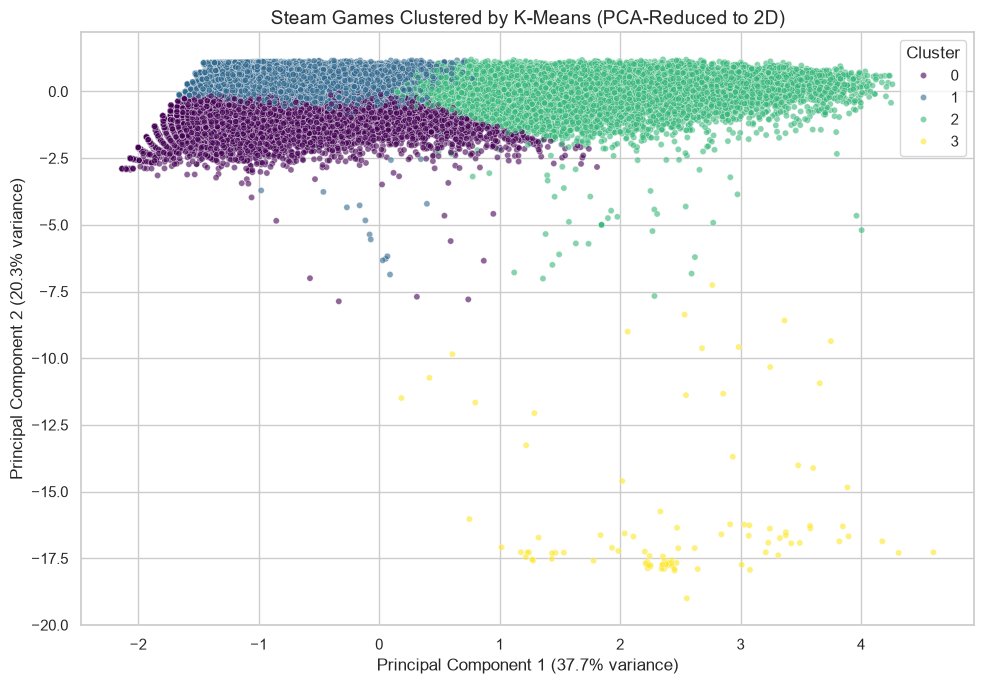

Generating Cluster Profile Bar Charts...


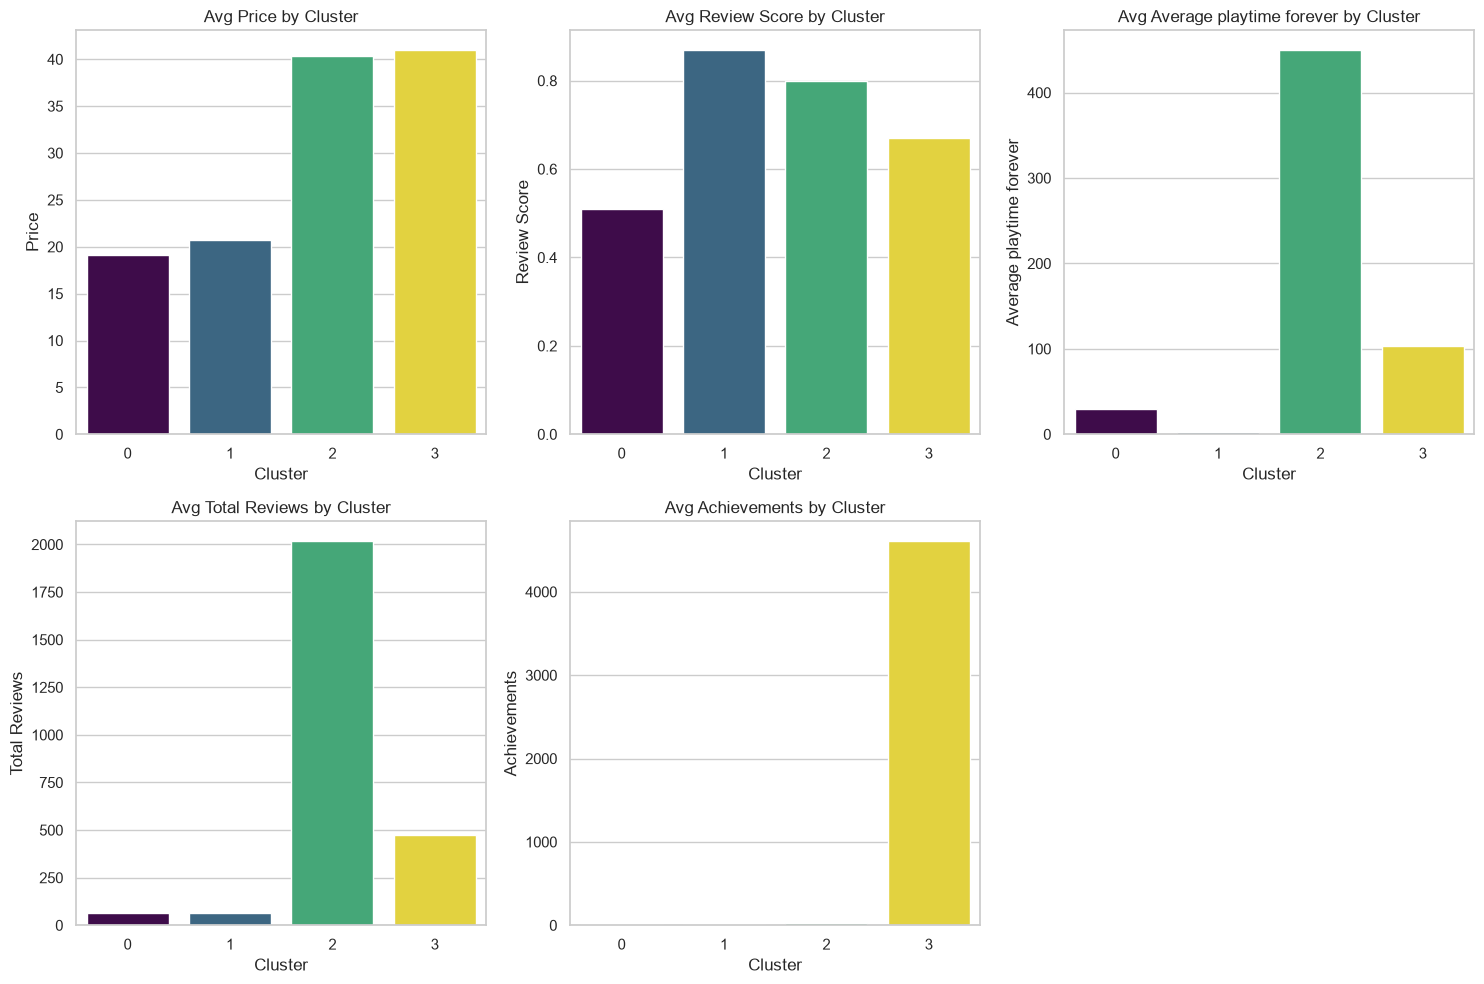

In [15]:
# ==========================================
# STEP 6: Visualizations
# ==========================================
sns.set_theme(style="whitegrid")
palette = "viridis"

# --- PLOT 1: PCA Scatter Plot ---
print("\nGenerating PCA Scatter Plot...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=clean_df["Cluster"], 
    palette=palette, 
    alpha=0.6,
    s=20
)
plt.title("Steam Games Clustered by K-Means (PCA-Reduced to 2D)", fontsize=14)
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

# --- PLOT 2: Cluster Profile Bar Charts ---
print("Generating Cluster Profile Bar Charts...")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Plot a bar chart for each of the 5 features
for i, col in enumerate(feature_cols):
    sns.barplot(
        x=cluster_profile.index, 
        y=cluster_profile[col], 
        ax=axes[i], 
        palette=palette,
        hue=cluster_profile.index,
        legend=False
    )
    axes[i].set_title(f"Avg {col} by Cluster", fontsize=12)
    axes[i].set_ylabel(col)
    axes[i].set_xlabel("Cluster")

# Hide the 6th empty subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()